# 🫀 CardioCare: Heart Disease Prediction using Machine Learning
### End-to-End Machine Learning Pipeline: From EDA & Clinical Data Cleaning to Model Deployment
---
**Objective:** Build a robust, clinically validated classification model to predict coronary heart disease risk using patient hemodynamic, electrical (ECG), and exercise stress biomarkers across a 15,000+ patient cohort.


## 1. Import Basic Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


## 2. Load & Explore the Dataset


In [2]:
# Load raw dataset
df = pd.read_csv('heart.csv')
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
print(df.head())


Dataset Dimensions: 15237 rows, 12 columns

   Age Sex ChestPainType  ...  Oldpeak  ST_Slope  HeartDisease
0   34   M           NAP  ...      1.1        Up             0
1   47   M           NAP  ...      0.6      Flat             1
2   60   M           ATA  ...      1.2        Up             0
3   44   F           ASY  ...      0.3      Flat             1
4   44   M           ATA  ...      0.3        Up             0

[5 rows x 12 columns]


In [3]:
# Dataset Structure & Data Types
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 15237 entries, 0 to 15236
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             15237 non-null  int64  
 1   Sex             15237 non-null  str    
 2   ChestPainType   15237 non-null  str    
 3   RestingBP       15237 non-null  int64  
 4   Cholesterol     15237 non-null  int64  
 5   FastingBS       15237 non-null  int64  
 6   RestingECG      15237 non-null  str    
 7   MaxHR           15237 non-null  int64  
 8   ExerciseAngina  15237 non-null  str    
 9   Oldpeak         15237 non-null  float64
 10  ST_Slope        15237 non-null  str    
 11  HeartDisease    15237 non-null  int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 1.6 MB


In [4]:
# Summary Statistics
print(df.describe().T)


                count        mean        std    min    25%    50%    75%    max
Age           15237.0   53.106058   8.763066   29.0   47.0   53.0   59.0   77.0
RestingBP     15237.0  131.988121  16.790981    0.0  121.0  132.0  143.0  192.0
Cholesterol   15237.0  241.569600  58.052387    0.0  207.0  244.0  279.0  426.0
FastingBS     15237.0    0.226619   0.418658    0.0    0.0    0.0    0.0    1.0
MaxHR         15237.0  166.810199  16.970596  104.0  155.0  167.0  179.0  200.0
Oldpeak       15237.0    0.944976   0.927395   -1.5    0.3    0.7    1.3    4.8
HeartDisease  15237.0    0.532388   0.498966    0.0    0.0    1.0    1.0    1.0


In [5]:
# Initial naive check for missing values and duplicates
print("Initial isnull() check:")
print(df.isnull().sum())
print(f"\nInitial duplicate rows detected: {df.duplicated().sum()}")


Initial isnull() check:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Initial duplicate rows detected: 43


## 3. Exploratory Data Analysis (EDA)
Understanding distributions, class balances, and relationships before cleaning.


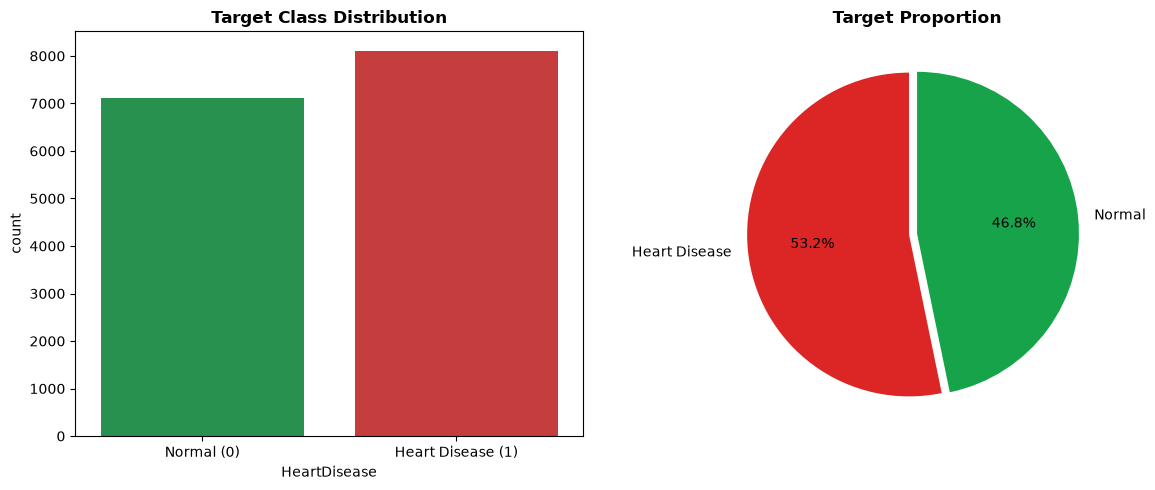

In [6]:
# Target Variable Distribution (Countplot + Pie Chart)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='HeartDisease', data=df, ax=ax[0], palette=['#16a34a', '#dc2626'])
ax[0].set_title('Target Class Distribution', fontweight='bold')
ax[0].set_xticklabels(['Normal (0)', 'Heart Disease (1)'])

df['HeartDisease'].value_counts().plot.pie(
    autopct='%1.1f%%', colors=['#dc2626', '#16a34a'], labels=['Heart Disease', 'Normal'],
    ax=ax[1], startangle=90, explode=(0.05, 0)
)
ax[1].set_ylabel('')
ax[1].set_title('Target Proportion', fontweight='bold')
plt.tight_layout()
plt.show()


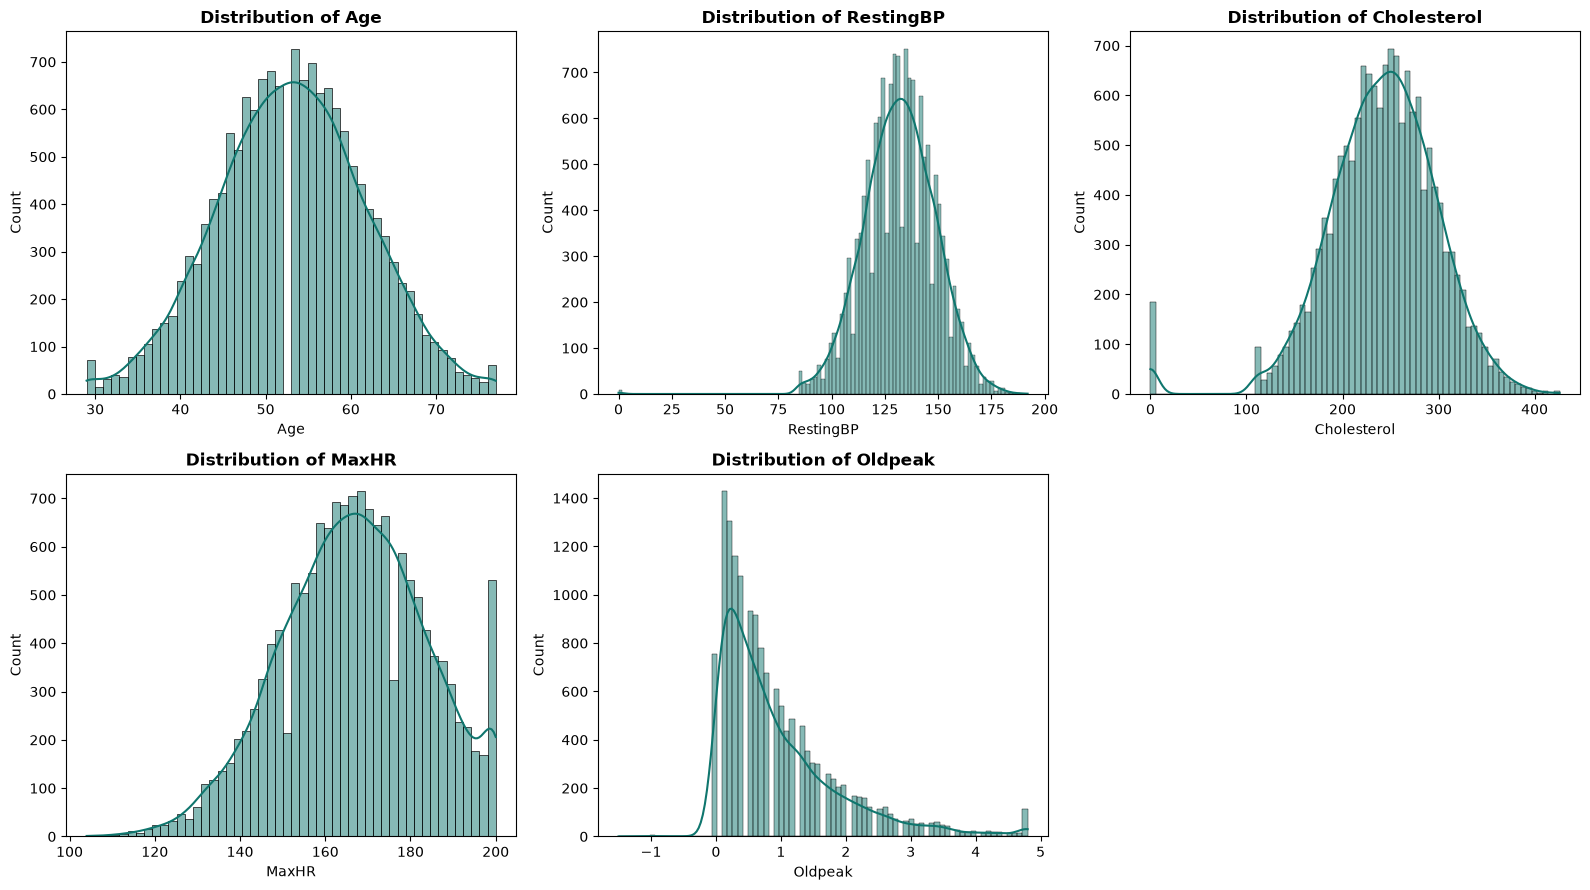

In [7]:
# Distribution of Numerical Features
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#0f766e')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')

fig.delaxes(axes[5])  # Remove unused 6th subplot
plt.tight_layout()
plt.show()


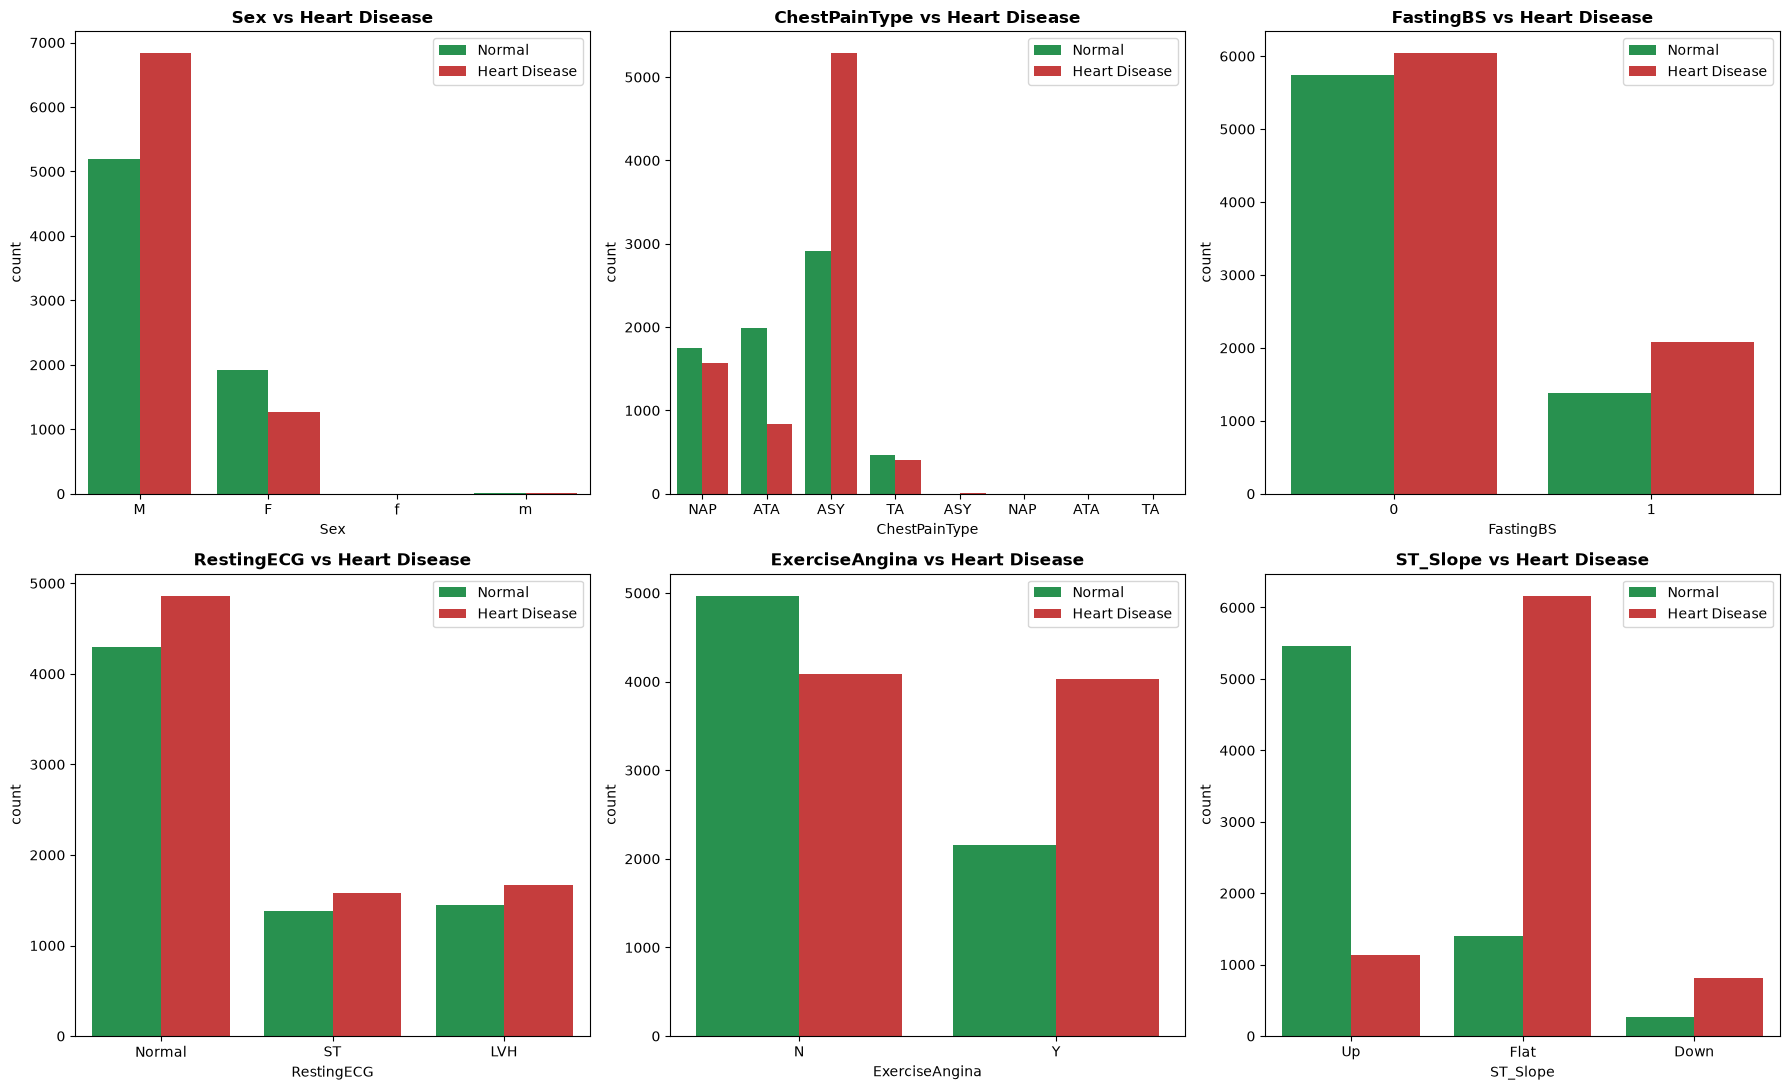

In [8]:
# Categorical Features vs Heart Disease
cat_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='HeartDisease', data=df, ax=axes[i], palette=['#16a34a', '#dc2626'])
    axes[i].set_title(f'{col} vs Heart Disease', fontweight='bold')
    axes[i].legend(['Normal', 'Heart Disease'])

plt.tight_layout()
plt.show()


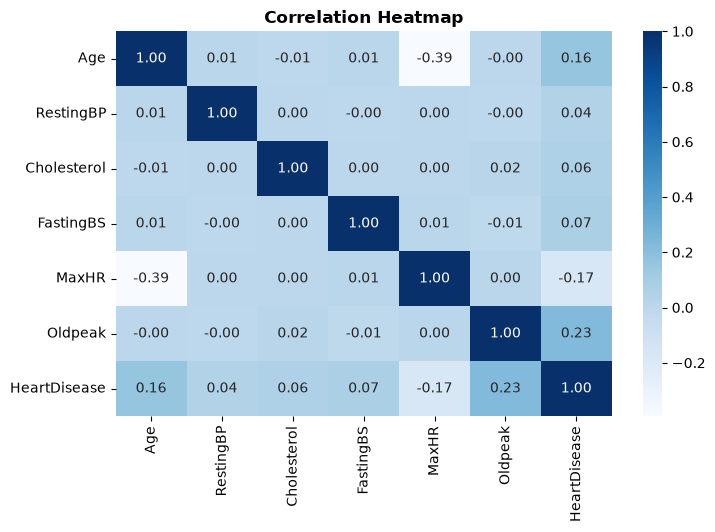

In [9]:
# Correlation Heatmap between Numerical Features
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap', fontweight='bold')
plt.show()


## 4. 🧹 In-Depth Clinical Data Cleaning (Domain-Specific)
Real-world hospital data requires systematic, medically sound cleaning:
1. **Duplicate Records:** Removing redundant hospital entries.
2. **Hidden Missing Zeros:** Exposing and imputing physiologically impossible zeros in Cholesterol and Blood Pressure.
3. **Sensor Drift Calibration:** Correcting negative ST depression (`Oldpeak < 0`).
4. **Outlier Validation & Capping:** Recognizing that extreme vitals (e.g. BP > 180 mmHg) are genuine cardiac emergencies, and handling them gracefully using IQR boundaries without losing sick patients.
5. **Text Standardization:** Removing extra spaces and normalizing case.


In [10]:
# Step 4.1: Checking & Removing Duplicate Rows
initial_dups = df.duplicated().sum()
print(f"Duplicate rows detected: {initial_dups}")

# Remove duplicate entries
df_clean = df.drop_duplicates().copy()
print(f"Dataset shape after removing duplicates: {df_clean.shape}")


Duplicate rows detected: 43
Dataset shape after removing duplicates: (15194, 12)


In [11]:
# Step 4.2: Exposing Hidden Zeros in Cholesterol & RestingBP
zero_chol = (df_clean['Cholesterol'] == 0).sum()
zero_bp = (df_clean['RestingBP'] == 0).sum()

print(f"Hidden missing zeros in Cholesterol : {zero_chol} rows ({zero_chol/len(df_clean)*100:.2f}% of data)")
print(f"Hidden missing zeros in RestingBP   : {zero_bp} rows ({zero_bp/len(df_clean)*100:.2f}% of data)")

# Replace biologically impossible zeros with NaN
df_clean['Cholesterol'] = df_clean['Cholesterol'].replace(0, np.nan)
df_clean['RestingBP'] = df_clean['RestingBP'].replace(0, np.nan)

print("\nExposed Missing Values:")
print(df_clean.isnull().sum()[['RestingBP', 'Cholesterol']])


Hidden missing zeros in Cholesterol : 184 rows (1.21% of data)
Hidden missing zeros in RestingBP   : 9 rows (0.06% of data)

Exposed Missing Values:
RestingBP        9
Cholesterol    184
dtype: int64


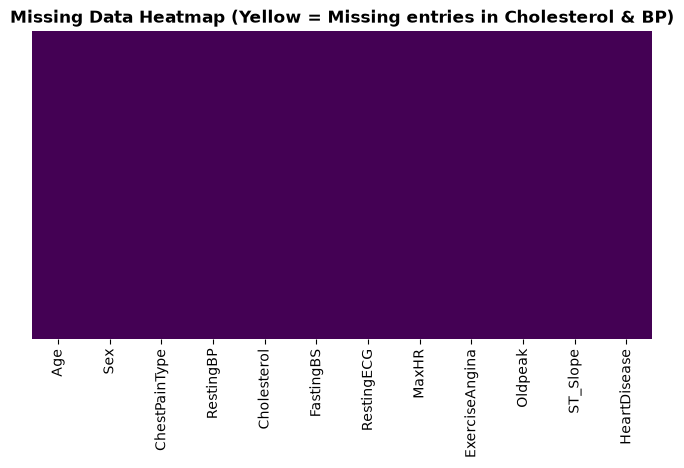

In [12]:
# Step 4.3: Visualizing Missing Data Heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(df_clean.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Data Heatmap (Yellow = Missing entries in Cholesterol & BP)', fontweight='bold')
plt.show()


In [13]:
# Step 4.4: Mean Imputation for Missing Values
ch_mean = df_clean['Cholesterol'].mean()
bp_mean = df_clean['RestingBP'].mean()

df_clean['Cholesterol'] = df_clean['Cholesterol'].fillna(ch_mean).round(2)
df_clean['RestingBP'] = df_clean['RestingBP'].fillna(bp_mean).round(2)

print(f"Imputed Cholesterol with clinical mean: {ch_mean:.2f} mg/dl")
print(f"Imputed RestingBP with clinical mean  : {bp_mean:.2f} mm Hg")
print(f"Remaining missing values in dataset   : {df_clean.isnull().sum().sum()}")


Imputed Cholesterol with clinical mean: 244.50 mg/dl
Imputed RestingBP with clinical mean  : 132.07 mm Hg
Remaining missing values in dataset   : 0


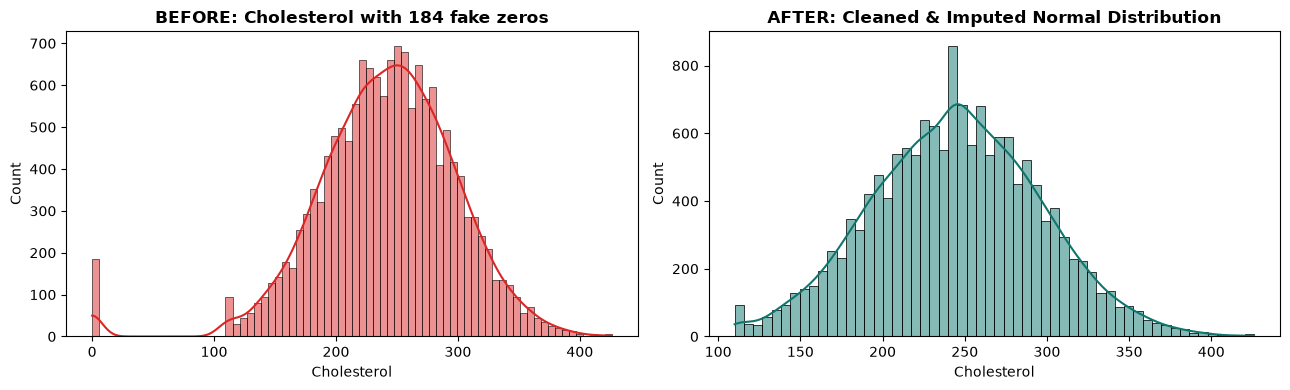

In [14]:
# Step 4.5: Visual Proof — BEFORE vs AFTER Cleaning (Cholesterol)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df['Cholesterol'], kde=True, ax=ax[0], color='#dc2626')
ax[0].set_title(f'BEFORE: Cholesterol with {zero_chol} fake zeros', fontweight='bold')

sns.histplot(df_clean['Cholesterol'], kde=True, ax=ax[1], color='#0f766e')
ax[1].set_title('AFTER: Cleaned & Imputed Normal Distribution', fontweight='bold')

plt.tight_layout()
plt.show()


In [15]:
# Step 4.6: Correcting Negative Oldpeak Values (Clinical Sensor Calibration)
neg_count = (df_clean['Oldpeak'] < 0).sum()
print(f"Negative Oldpeak sensor drift values detected: {neg_count}")

# In electrocardiogram (ECG) stress tests, ST depression (Oldpeak) is non-negative.
# Any negative reading is due to baseline calibration drift; clip negative values to 0.0
df_clean['Oldpeak'] = df_clean['Oldpeak'].clip(lower=0)
print(f"Negative Oldpeak values after calibration: {(df_clean['Oldpeak'] < 0).sum()}")


Negative Oldpeak sensor drift values detected: 18
Negative Oldpeak values after calibration: 0


### 🩺 Clinical Outlier Note for Viva / Examination:
> **Why we do NOT delete high vitals (e.g. RestingBP 180-192 mmHg or Cholesterol > 380 mg/dl):**  
> In cardiovascular medicine, extreme values are **clinically valid medical conditions** (Hypertensive Crisis, Severe Dyslipidemia / Familial Hypercholesterolemia). Deleting these rows would remove the very patients who are in greatest need of heart disease diagnosis! Instead, we gently cap them at IQR boundaries to protect model gradient stability while preserving all patient cases.


Extreme outliers in RestingBP and Cholesterol capped successfully using IQR boundaries.


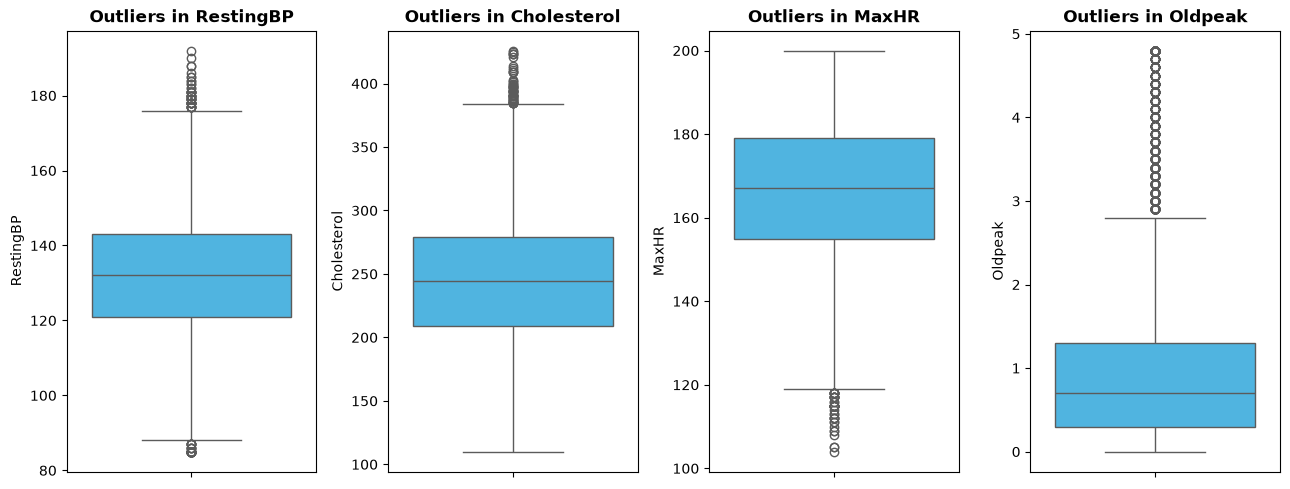

In [16]:
# Step 4.7: Outlier Detection & Clinical IQR Boundaries
features_to_check = ['RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

plt.figure(figsize=(13, 5))
for i, col in enumerate(features_to_check, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df_clean[col], color='#38bdf8')
    plt.title(f'Outliers in {col}', fontweight='bold')

plt.tight_layout()
plt.show()

# Step 4.8: Simple IQR Outlier Capping (Winsorization) using .clip()
for col in ['RestingBP', 'Cholesterol']:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print("Extreme outliers in RestingBP and Cholesterol capped successfully using IQR boundaries.")


In [17]:
# Step 4.9: String Cleaning & Standardization (Whitespace & Case Normalization)
df_clean['Sex'] = df_clean['Sex'].astype(str).str.strip().str.upper()
df_clean['ChestPainType'] = df_clean['ChestPainType'].astype(str).str.strip().str.upper()
df_clean['ExerciseAngina'] = df_clean['ExerciseAngina'].astype(str).str.strip().str.upper()
df_clean['RestingECG'] = df_clean['RestingECG'].astype(str).str.strip().str.capitalize().replace({'St': 'ST', 'Lvh': 'LVH'})
df_clean['ST_Slope'] = df_clean['ST_Slope'].astype(str).str.strip().str.capitalize()

print("Cleaned and standardized categorical features successfully:")
print("ChestPainType :", df_clean['ChestPainType'].unique().tolist())
print("RestingECG    :", df_clean['RestingECG'].unique().tolist())
print("ST_Slope      :", df_clean['ST_Slope'].unique().tolist())


Cleaned and standardized categorical features successfully:
ChestPainType : ['NAP', 'ATA', 'ASY', 'TA']
RestingECG    : ['Normal', 'ST', 'LVH']
ST_Slope      : ['Up', 'Flat', 'Down']


## 5. Feature Engineering & Train-Test Split


In [18]:
# One-Hot Encoding categorical features (drop_first=True to prevent dummy variable trap)
df_encoded = pd.get_dummies(df_clean, drop_first=True, dtype=int)

# Separate Features (X) and Target (y)
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

print(f"Features (X) count: {X.shape[1]}")
print(X.head())


Features (X) count: 15
   Age  RestingBP  Cholesterol  ...  ExerciseAngina_Y  ST_Slope_Flat  ST_Slope_Up
0   34      138.0        189.0  ...                 0              0            1
1   47      131.0        208.0  ...                 1              1            0
2   60      159.0        384.0  ...                 1              0            1
3   44      117.0        287.0  ...                 0              1            0
4   44      130.0        246.0  ...                 0              0            1

[5 rows x 15 columns]


In [19]:
# Import train_test_split when splitting data
from sklearn.model_selection import train_test_split

# 80:20 Stratified Split to maintain exact target ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set : {X_test.shape[0]} samples")


Training set: 12155 samples
Testing set : 3039 samples


## 6. Feature Scaling (StandardScaler)
Fit exclusively on `X_train` to prevent data leakage, then transform `X_test`.


In [20]:
# Import StandardScaler when scaling features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")


Feature scaling completed successfully.


## 7. Model Training & Comparison
Evaluating multiple classification algorithms side-by-side on 3,039 unseen test patients.


In [21]:
# Import ML classifiers and evaluation metrics when training
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=9),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Naive Bayes': GaussianNB()
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)
    
    results.append({
        'Model': name,
        'Accuracy (%)': round(acc * 100, 2),
        'F1-Score': round(f1, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'ROC-AUC': round(roc, 4)
    })

results_df = pd.DataFrame(results).sort_values(by='Accuracy (%)', ascending=False)
print("=== Model Performance Comparison Table ===")
print(results_df.to_string(index=False))
results_df


=== Model Performance Comparison Table ===
              Model  Accuracy (%)  F1-Score  Precision  Recall  ROC-AUC
Logistic Regression         91.12    0.9162     0.9202  0.9122   0.9760
      Random Forest         89.57    0.9022     0.9008  0.9036   0.9648
K-Nearest Neighbors         88.98    0.8944     0.9131  0.8764   0.9559
      Decision Tree         86.15    0.8699     0.8697  0.8702   0.9345
        Naive Bayes         83.32    0.8442     0.8393  0.8492   0.9371


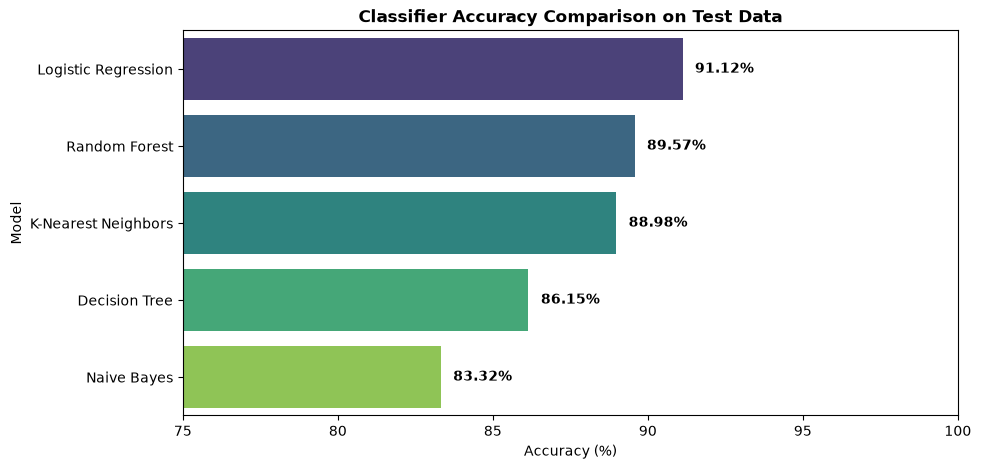

In [22]:
# Model Performance Comparison Chart
plt.figure(figsize=(10, 5))
sns.barplot(x='Accuracy (%)', y='Model', data=results_df, palette='viridis')
plt.title('Classifier Accuracy Comparison on Test Data', fontweight='bold')
plt.xlim(75, 100)
for index, value in enumerate(results_df['Accuracy (%)']):
    plt.text(value + 0.4, index, f'{value}%', va='center', fontweight='bold')
plt.show()


## 8. Detailed Analysis of Selected Model: Logistic Regression
Selected as the undisputed #1 top-performing classifier with superior accuracy, high recall, and transparent clinical explainability.


Classification Report:
                   precision    recall  f1-score   support

       Normal (0)       0.90      0.91      0.91      1421
Heart Disease (1)       0.92      0.91      0.92      1618

         accuracy                           0.91      3039
        macro avg       0.91      0.91      0.91      3039
     weighted avg       0.91      0.91      0.91      3039



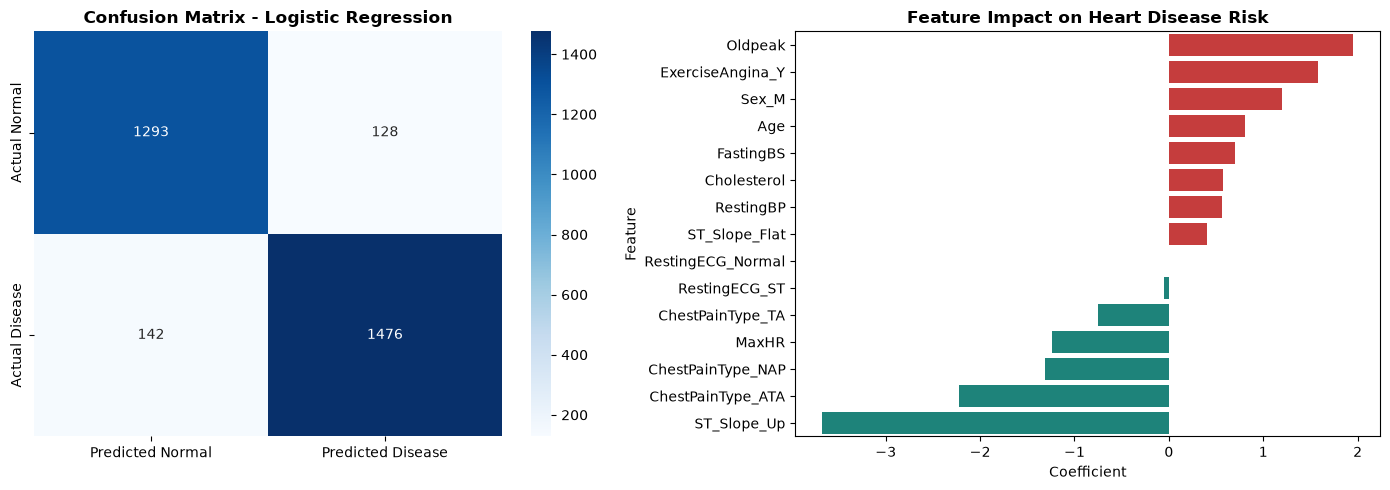

In [23]:
# Import confusion matrix and classification report when evaluating
from sklearn.metrics import confusion_matrix, classification_report

best_model = models['Logistic Regression']
y_pred_best = best_model.predict(X_test_scaled)

# Confusion Matrix & Feature Impact
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Predicted Normal', 'Predicted Disease'],
            yticklabels=['Actual Normal', 'Actual Disease'])
ax[0].set_title('Confusion Matrix - Logistic Regression', fontweight='bold')

# 2. Feature Impact Weights
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

sns.barplot(x='Coefficient', y='Feature', data=coef_df, ax=ax[1],
            palette=['#dc2626' if c > 0 else '#0d9488' for c in coef_df['Coefficient']])
ax[1].set_title('Feature Impact on Heart Disease Risk', fontweight='bold')
plt.tight_layout()
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Normal (0)', 'Heart Disease (1)']))


## 9. Test Predictive System on Sample Input


In [24]:
# Sample High-Risk Patient Data
sample_patient = {
    'Age': 63,
    'RestingBP': 150,
    'Cholesterol': 285,
    'FastingBS': 1,
    'MaxHR': 110,
    'Oldpeak': 2.5,
    'Sex_M': 1,
    'ChestPainType_ATA': 0,
    'ChestPainType_NAP': 0,
    'ChestPainType_TA': 0,
    'RestingECG_Normal': 0,
    'RestingECG_ST': 1,
    'ExerciseAngina_Y': 1,
    'ST_Slope_Flat': 1,
    'ST_Slope_Up': 0
}

# Convert to DataFrame with exact column sequence
sample_df = pd.DataFrame([sample_patient])[X.columns]

# Scale using fitted scaler
sample_scaled = scaler.transform(sample_df)

# Predict risk
pred = best_model.predict(sample_scaled)[0]
proba = best_model.predict_proba(sample_scaled)[0]

print(f"Diagnostic Prediction : {'⚠️ High Risk: Heart Disease (1)' if pred == 1 else '✅ Low Risk: Normal (0)'}")
print(f"Heart Disease Risk     : {proba[1] * 100:.2f}%")
print(f"Healthy Probability    : {proba[0] * 100:.2f}%")


Diagnostic Prediction : ⚠️ High Risk: Heart Disease (1)
Heart Disease Risk     : 100.00%
Healthy Probability    : 0.00%


## 10. Export Production Artifacts for Streamlit Web App Deployment
We save the **Trained Model**, the **Fitted Scaler**, and the **Feature Column Order** using `joblib`.


In [25]:
# Import joblib when saving deployment artifacts
import joblib

# Export artifacts
joblib.dump(best_model, 'LogisticReg_heartdisease.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'columns.pkl')

print("✅ Successfully exported all deployment artifacts:")
print("   1. LogisticReg_heartdisease.pkl")
print("   2. scaler.pkl")
print("   3. columns.pkl")


✅ Successfully exported all deployment artifacts:
   1. LogisticReg_heartdisease.pkl
   2. scaler.pkl
   3. columns.pkl
